
================ RAW DATA CHECK ================

Shape: (7422, 35)
   calendar_month       date  community  consumption_unit_total
0          201704 2017-04-01        111             4539462.390
1          201705 2017-05-01        111             6571218.922
2          201706 2017-06-01        111             7133896.936
3          201707 2017-07-01        111             6914346.915
4          201708 2017-08-01        111             1635243.326

================ BASIC EDA ================

         Unnamed: 0          ID  consumption_unit_total  calendar_month  \
count   7422.000000        7422            7.422000e+03     7422.000000   
unique          NaN        7422                     NaN             NaN   
top             NaN  202002-991                     NaN             NaN   
freq            NaN           1                     NaN             NaN   
mean    3711.500000         NaN            1.893047e+07   201828.995284   
min        1.000000         NaN            0.000000

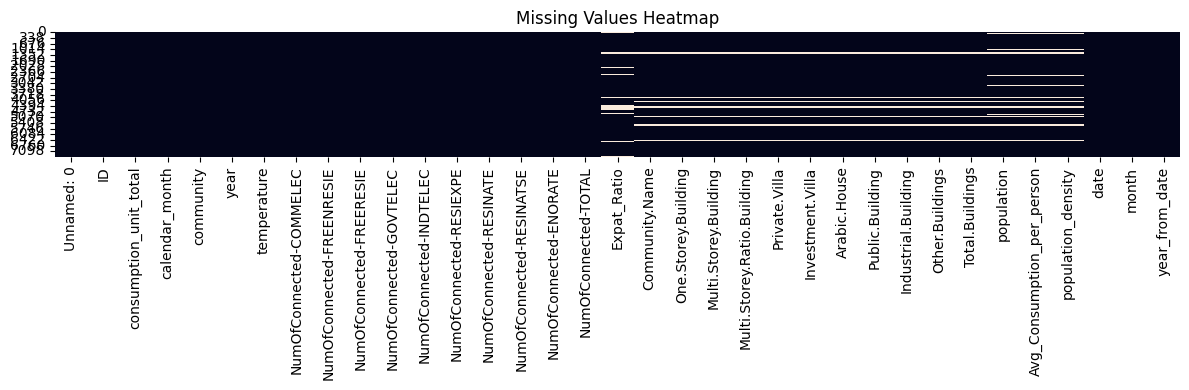

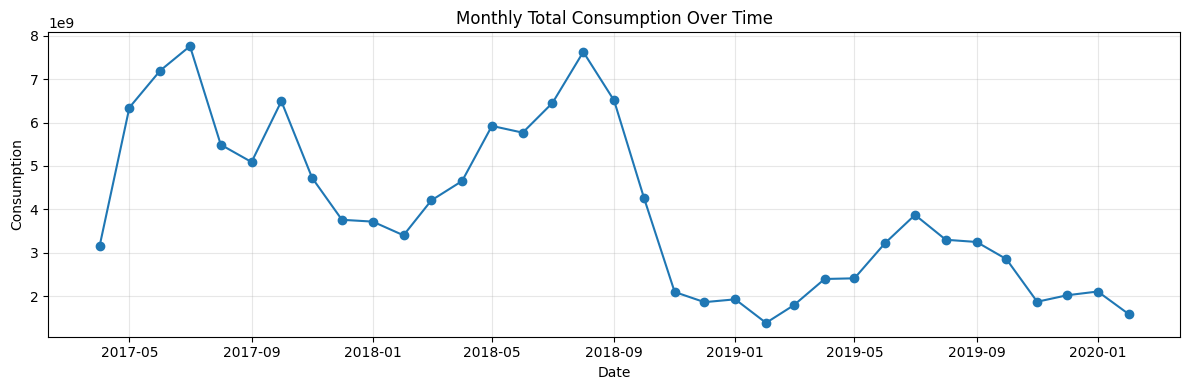

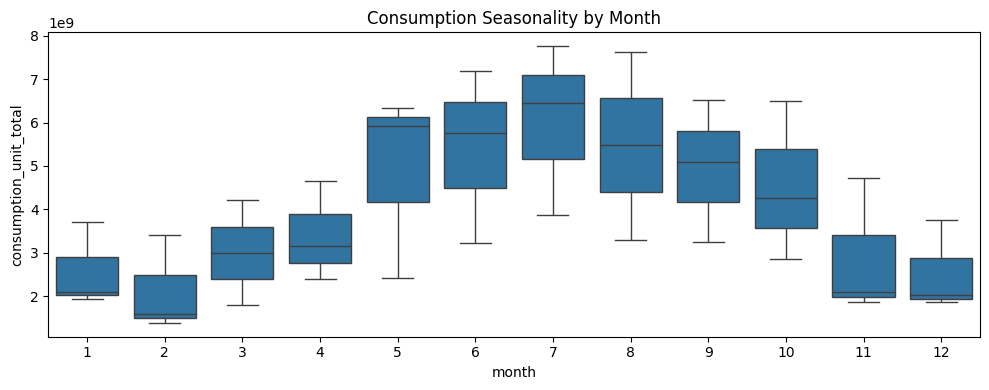

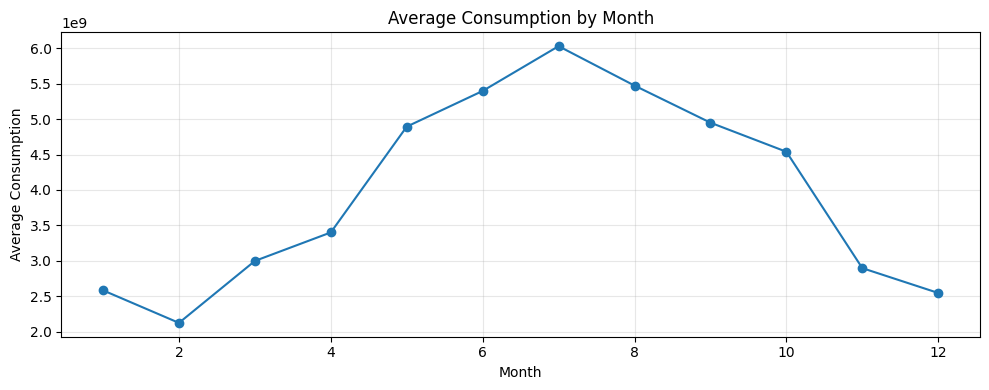


================ PANEL DATA ================

Shape: (6723, 35)
Feature columns: ['lag_1', 'lag_2', 'lag_3', 'temperature', 'month', 'year', 'community']
        date  community  consumption_unit_total        lag_1        lag_2  \
0 2017-07-01        111             6914346.915  7133896.936  6571218.922   
1 2017-08-01        111             1635243.326  6914346.915  7133896.936   
2 2017-09-01        111             4972243.927  1635243.326  6914346.915   
3 2017-10-01        111             6308743.483  4972243.927  1635243.326   
4 2017-11-01        111             4849176.933  6308743.483  4972243.927   

         lag_3  temperature  month  year  community  
0  4539462.390         39.2      7  2017        111  
1  6571218.922         38.2      8  2017        111  
2  7133896.936         35.5      9  2017        111  
3  6914346.915         31.9     10  2017        111  
4  1635243.326         27.2     11  2017        111  

Train panel shape: (5199, 35)
Test panel shape : (1524, 3

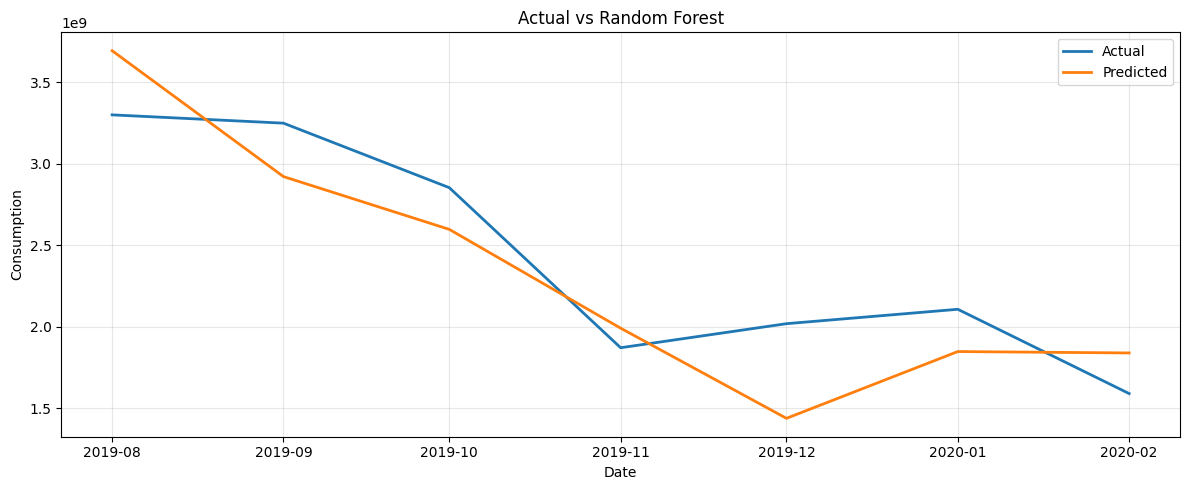

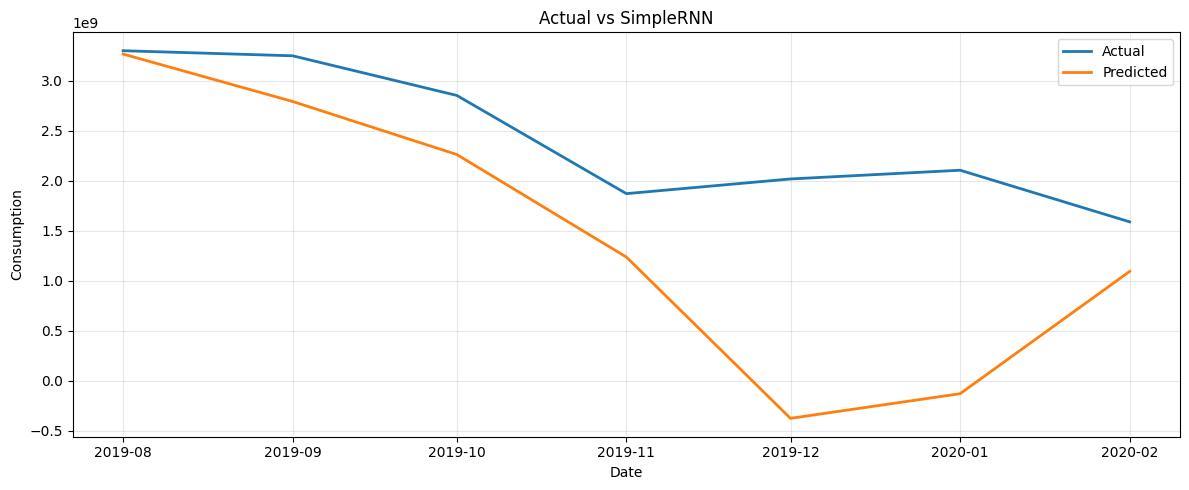

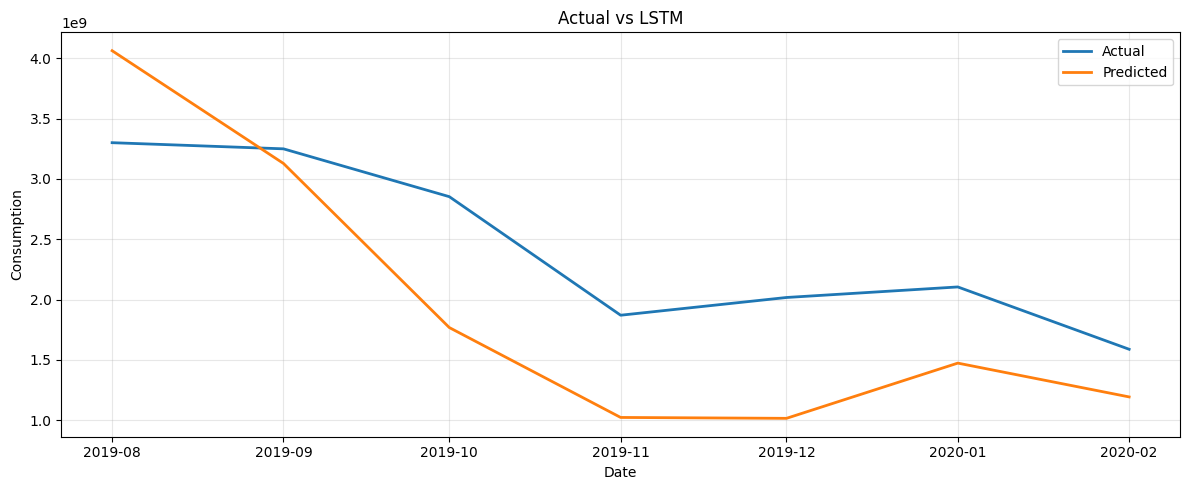

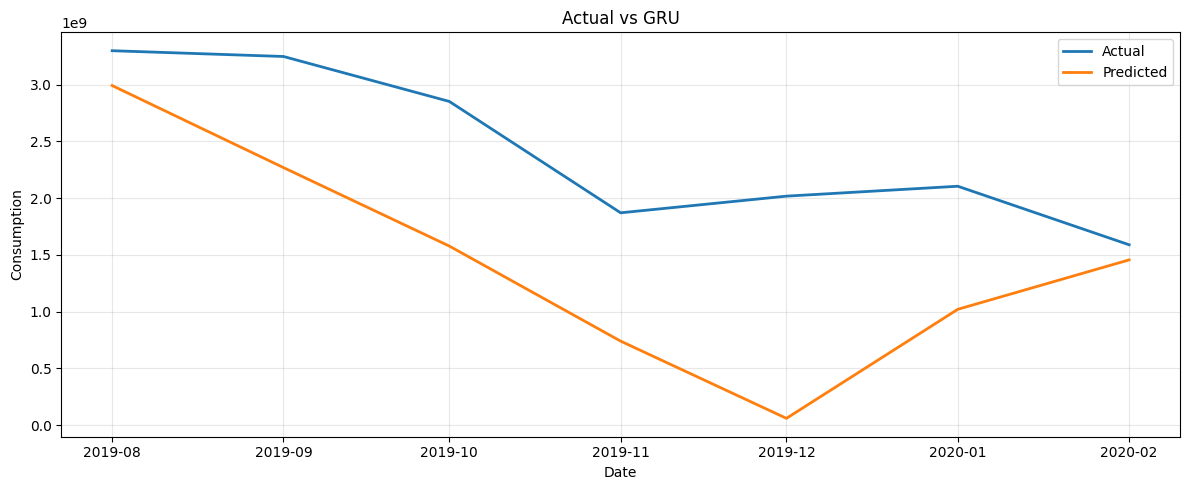

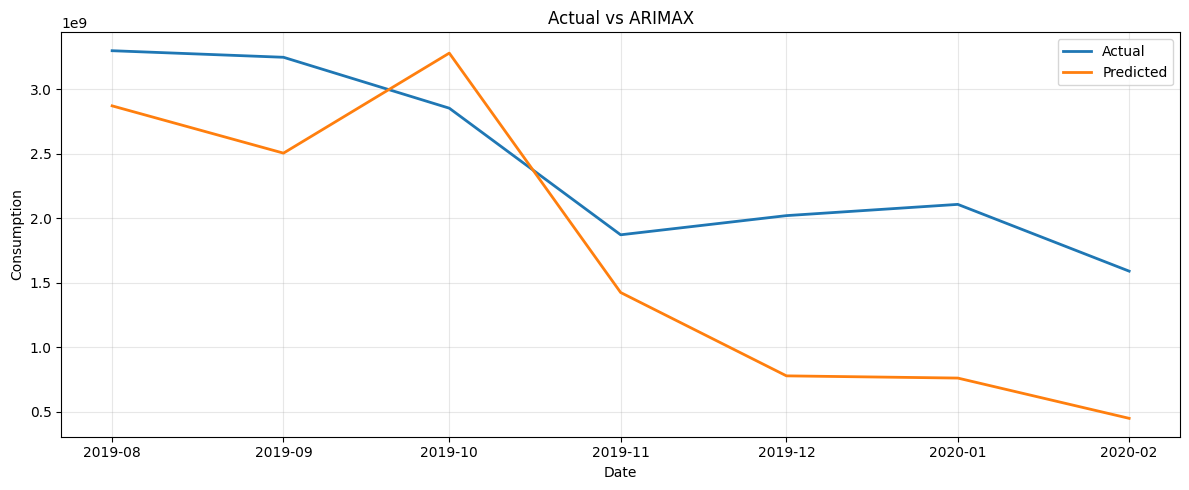

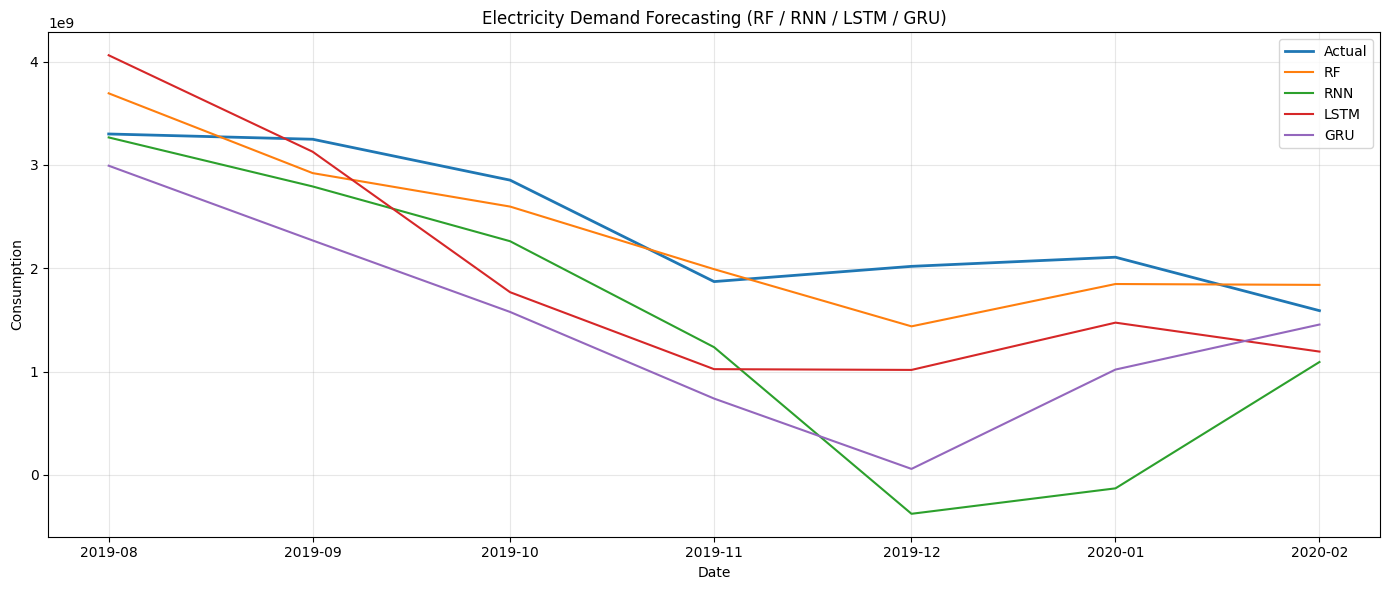


================ MODEL COMPARISON ================

              Model           MAE          RMSE        R2          MAPE  \
0     Random Forest  1.998216e+06  4.977276e+06  0.891542    772.768177   
1              LSTM  3.860815e+06  6.906148e+06  0.793484  15526.593802   
2               GRU  5.096660e+06  6.914436e+06  0.792988  26308.074343   
3         SimpleRNN  5.353493e+06  7.495799e+06  0.756714  84160.182245   
4  ARIMAX (SARIMAX)  8.252130e+08  9.086304e+08 -0.996989     38.835581   

        sMAPE       WAPE  
0   22.552955  17.924514  
1   67.851223  33.826408  
2  104.868656  44.654226  
3  102.842331  46.904463  
4   53.622812  33.990038  

================ BEST PARAMETERS ================

Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
ARIMAX order: (1, 0, 1)
ARIMAX seasonal_order: (1, 1, 0, 12)
SimpleRNN: {'batch_size': 16, 'dropout': 0.2, 'epochs': 40, 'lr': 0.001, 'units1': 64, 'units2': 16}
LSTM: {'batch_size'

In [ ]:
# =========================================================
# ELECTRICITY DEMAND FORECASTING - COMPLETE FINAL CODE
# =========================================================
# This version:
# - handles calendar_month in YYYYMM format
# - uses community-level panel data for RF / SimpleRNN / LSTM / GRU
# - uses monthly aggregated data for ARIMAX
# - fixes duplicate community grouping issues
# - uses safer metrics: MAE, RMSE, R2, MAPE, sMAPE, WAPE
# - creates individual Actual vs Predicted plots
# =========================================================

# -----------------------------
# 1) IMPORT LIBRARIES
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

import itertools
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 2) REPRODUCIBILITY
# -----------------------------
np.random.seed(42)
random.seed(42)

# -----------------------------
# 3) CONFIG
# -----------------------------
FILE_PATH = "Dataset.csv"

TARGET = "consumption_unit_total"
COMMUNITY_COL = "community"
CALENDAR_COL = "calendar_month"
DATE_COL = "date"

TRAIN_RATIO = 0.8

# Panel model settings
MAX_LAG_PANEL = 3
SEQ_LENGTH = 3

# ARIMAX settings
SEASONAL_PERIOD = 12

# -----------------------------
# 4) LOAD DATA
# -----------------------------
df_raw = pd.read_csv(FILE_PATH)
df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

# -----------------------------
# 5) BASIC CLEANING
# -----------------------------
important_numeric_cols = [TARGET, CALENDAR_COL, "year", "temperature", COMMUNITY_COL]

for col in important_numeric_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

if CALENDAR_COL not in df_raw.columns:
    raise ValueError(f"Column '{CALENDAR_COL}' not found in dataset.")

# calendar_month is YYYYMM, e.g. 201704
df_raw[DATE_COL] = pd.to_datetime(
    df_raw[CALENDAR_COL].astype("Int64").astype(str),
    format="%Y%m",
    errors="coerce"
)

df_raw["month"] = df_raw[DATE_COL].dt.month
df_raw["year_from_date"] = df_raw[DATE_COL].dt.year

if "year" in df_raw.columns:
    df_raw["year"] = df_raw["year"].fillna(df_raw["year_from_date"])
else:
    df_raw["year"] = df_raw["year_from_date"]

if COMMUNITY_COL not in df_raw.columns:
    raise ValueError(f"Column '{COMMUNITY_COL}' not found in dataset.")

# Drop rows missing essential values
df_raw = df_raw.dropna(subset=[DATE_COL, COMMUNITY_COL, TARGET]).copy()

# Sort
df_raw = df_raw.sort_values([COMMUNITY_COL, DATE_COL]).reset_index(drop=True)

print("\n================ RAW DATA CHECK ================\n")
print("Shape:", df_raw.shape)
print(df_raw[[CALENDAR_COL, DATE_COL, COMMUNITY_COL, TARGET]].head())

# -----------------------------
# 6) BASIC EDA
# -----------------------------
print("\n================ BASIC EDA ================\n")
print(df_raw.describe(include="all"))

missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nMissing values:\n", missing if len(missing) else "No missing values found.")

plt.figure(figsize=(12, 4))
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

# Monthly total consumption trend
monthly_total_eda = df_raw.groupby(DATE_COL, as_index=False)[TARGET].sum()

plt.figure(figsize=(12, 4))
plt.plot(monthly_total_eda[DATE_COL], monthly_total_eda[TARGET], marker="o")
plt.title("Monthly Total Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Monthly seasonality
season_df = monthly_total_eda.copy()
season_df["month"] = season_df[DATE_COL].dt.month

plt.figure(figsize=(10, 4))
sns.boxplot(x="month", y=TARGET, data=season_df)
plt.title("Consumption Seasonality by Month")
plt.tight_layout()
plt.show()

month_mean = season_df.groupby("month")[TARGET].mean()
plt.figure(figsize=(10, 4))
plt.plot(month_mean.index, month_mean.values, marker="o")
plt.title("Average Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 7) METRIC FUNCTIONS
# -----------------------------
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def wape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom <= eps:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom * 100

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = safe_mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)
    wape_val = wape(y_true, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"R2    : {r2:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"sMAPE : {smape_val:.2f}%")
    print(f"WAPE  : {wape_val:.2f}%")

    return mae, rmse, r2, mape, smape_val, wape_val

def plot_actual_vs_pred_simple(dates, actual, pred, title):
    plt.figure(figsize=(12, 5))
    plt.plot(dates, actual, label="Actual", linewidth=2)
    plt.plot(dates, pred, label="Predicted", linewidth=2)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Consumption")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 8) PANEL DATA PREPARATION
# -----------------------------
candidate_cols = [TARGET, "temperature", "month", "year", COMMUNITY_COL]

extra_numeric = df_raw.select_dtypes(include=[np.number]).columns.tolist()
for col in extra_numeric:
    if col not in candidate_cols and col != CALENDAR_COL:
        candidate_cols.append(col)

candidate_cols = [c for c in candidate_cols if c in df_raw.columns]

panel_df = df_raw[[DATE_COL] + candidate_cols].copy()
panel_df = panel_df.loc[:, ~panel_df.columns.duplicated()].copy()

# Create lags inside each community
panel_df = panel_df.sort_values([COMMUNITY_COL, DATE_COL]).reset_index(drop=True)

for lag in range(1, MAX_LAG_PANEL + 1):
    panel_df[f"lag_{lag}"] = panel_df.groupby(COMMUNITY_COL)[TARGET].shift(lag)

panel_df = panel_df.dropna(
    subset=[DATE_COL, COMMUNITY_COL, TARGET] + [f"lag_{i}" for i in range(1, MAX_LAG_PANEL + 1)]
).reset_index(drop=True)

# -----------------------------
# 9) CHOOSE PANEL FEATURES
# -----------------------------
base_features = [f"lag_{i}" for i in range(1, MAX_LAG_PANEL + 1)]

optional_features = []
for col in ["temperature", "month", "year"]:
    if col in panel_df.columns:
        optional_features.append(col)

# Keep community only once for RF
if COMMUNITY_COL in panel_df.columns and COMMUNITY_COL not in optional_features:
    optional_features.append(COMMUNITY_COL)

feature_cols_panel = base_features + optional_features
feature_cols_panel = list(dict.fromkeys(feature_cols_panel))
feature_cols_panel = [c for c in feature_cols_panel if c in panel_df.columns]

print("\n================ PANEL DATA ================\n")
print("Shape:", panel_df.shape)
print("Feature columns:", feature_cols_panel)
print(panel_df[[DATE_COL, COMMUNITY_COL, TARGET] + feature_cols_panel].head())

# -----------------------------
# 10) TRAIN / TEST SPLIT FOR PANEL DATA
# -----------------------------
unique_dates = sorted(panel_df[DATE_COL].dropna().unique())
split_idx = int(len(unique_dates) * TRAIN_RATIO)
train_dates = unique_dates[:split_idx]
test_dates_only = unique_dates[split_idx:]

train_panel = panel_df[panel_df[DATE_COL].isin(train_dates)].copy()
test_panel = panel_df[panel_df[DATE_COL].isin(test_dates_only)].copy()

print("\nTrain panel shape:", train_panel.shape)
print("Test panel shape :", test_panel.shape)

# -----------------------------
# 11) RANDOM FOREST DATA
# -----------------------------
X_train_rf = train_panel[feature_cols_panel].copy()
X_test_rf = test_panel[feature_cols_panel].copy()
y_train_rf = train_panel[TARGET].copy()
y_test_rf = test_panel[TARGET].copy()

X_train_rf = X_train_rf.fillna(X_train_rf.median(numeric_only=True))
X_test_rf = X_test_rf.fillna(X_train_rf.median(numeric_only=True))

# -----------------------------
# 12) RANDOM FOREST TUNING
# -----------------------------
print("\n================ RANDOM FOREST TUNING ================\n")

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

best_rf_model = None
best_rf_params = None
best_rf_rmse = np.inf
best_rf_pred = None

for params in ParameterGrid(rf_param_grid):
    rf = RandomForestRegressor(random_state=42, **params)
    rf.fit(X_train_rf, y_train_rf)
    pred = rf.predict(X_test_rf)
    rmse = np.sqrt(mean_squared_error(y_test_rf, pred))

    if rmse < best_rf_rmse:
        best_rf_rmse = rmse
        best_rf_model = rf
        best_rf_params = params
        best_rf_pred = pred

print("Best RF Parameters:", best_rf_params)
rf_results = evaluate(y_test_rf, best_rf_pred, "Random Forest (Tuned)")

# -----------------------------
# 13) BUILD SEQUENCE DATA
# -----------------------------
# community must not be duplicated in the sequence feature tensor
seq_feature_cols = [TARGET] + [c for c in feature_cols_panel if c not in [TARGET, COMMUNITY_COL]]
seq_feature_cols = list(dict.fromkeys(seq_feature_cols))

panel_seq_df = panel_df[[DATE_COL, COMMUNITY_COL] + seq_feature_cols].copy()
panel_seq_df = panel_seq_df.loc[:, ~panel_seq_df.columns.duplicated()].copy()

print("\nColumns in panel_seq_df:")
print(panel_seq_df.columns.tolist())
print("Duplicate columns?", panel_seq_df.columns.duplicated().any())

train_seq_df = panel_seq_df[panel_seq_df[DATE_COL].isin(train_dates)].copy()
test_seq_df = panel_seq_df[panel_seq_df[DATE_COL].isin(test_dates_only)].copy()

# Scale only the sequence features
scaler_cols = seq_feature_cols
scaler = MinMaxScaler()

train_seq_df[scaler_cols] = scaler.fit_transform(train_seq_df[scaler_cols])
test_seq_df[scaler_cols] = scaler.transform(test_seq_df[scaler_cols])

def create_group_sequences(df_input, seq_length, feature_cols, community_col, date_col):
    X, y, meta = [], [], []

    for community_id, g in df_input.groupby(community_col):
        g = g.sort_values(date_col).reset_index(drop=True)
        data = g[feature_cols].values
        dates = g[date_col].values

        if len(g) <= seq_length:
            continue

        for i in range(len(g) - seq_length):
            X.append(data[i:i + seq_length])
            y.append(data[i + seq_length, 0])  # target is first column
            meta.append({
                "community": community_id,
                "date": dates[i + seq_length]
            })

    return np.array(X), np.array(y), pd.DataFrame(meta)

X_train_seq, y_train_seq, meta_train_seq = create_group_sequences(
    train_seq_df, SEQ_LENGTH, scaler_cols, COMMUNITY_COL, DATE_COL
)

# Build test sequences using the last train rows as prefix
test_sequence_parts = []

for community_id in panel_seq_df[COMMUNITY_COL].dropna().unique():
    g_train = train_seq_df[train_seq_df[COMMUNITY_COL] == community_id].sort_values(DATE_COL)
    g_test = test_seq_df[test_seq_df[COMMUNITY_COL] == community_id].sort_values(DATE_COL)

    if len(g_test) == 0:
        continue

    prefix = g_train.tail(SEQ_LENGTH)
    combined = pd.concat([prefix, g_test], axis=0)
    test_sequence_parts.append(combined)

if len(test_sequence_parts) == 0:
    raise ValueError("No test sequences could be created. Reduce SEQ_LENGTH or check split.")

test_seq_combined = pd.concat(test_sequence_parts, axis=0).reset_index(drop=True)
test_seq_combined = test_seq_combined.loc[:, ~test_seq_combined.columns.duplicated()].copy()

X_test_seq, y_test_seq, meta_test_seq = create_group_sequences(
    test_seq_combined, SEQ_LENGTH, scaler_cols, COMMUNITY_COL, DATE_COL
)

print("\n================ SEQUENCE DATA ================\n")
print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape :", X_test_seq.shape)

def inverse_target_only(arr_1d, scaler_obj, n_features):
    arr_1d = np.array(arr_1d).reshape(-1)
    temp = np.zeros((len(arr_1d), n_features))
    temp[:, 0] = arr_1d
    return scaler_obj.inverse_transform(temp)[:, 0]

y_train_seq_inv = inverse_target_only(y_train_seq, scaler, len(scaler_cols))
y_test_seq_inv = inverse_target_only(y_test_seq, scaler, len(scaler_cols))

# -----------------------------
# 14) DEEP LEARNING MODEL BUILDER
# -----------------------------
def build_dl_model(model_type, input_shape, units1=32, units2=16, dropout=0.2, lr=0.001):
    model = Sequential()

    if model_type == "SimpleRNN":
        model.add(SimpleRNN(units1, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(dropout))
        model.add(SimpleRNN(units2))
        model.add(Dropout(dropout))

    elif model_type == "LSTM":
        model.add(LSTM(units1, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(dropout))
        model.add(LSTM(units2))
        model.add(Dropout(dropout))

    elif model_type == "GRU":
        model.add(GRU(units1, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(dropout))
        model.add(GRU(units2))
        model.add(Dropout(dropout))

    else:
        raise ValueError("Unsupported model type")

    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

def tune_dl_model(model_type, X_train, y_train, X_test, y_test_inv, scaler_obj, n_features):
    param_grid = {
        "units1": [32, 64],
        "units2": [16, 32],
        "dropout": [0.2],
        "lr": [0.001],
        "batch_size": [16, 32],
        "epochs": [40]
    }

    best_model = None
    best_params = None
    best_pred_inv = None
    best_rmse = np.inf

    for params in ParameterGrid(param_grid):
        print(f"Tuning {model_type}: {params}")

        model = build_dl_model(
            model_type=model_type,
            input_shape=(X_train.shape[1], X_train.shape[2]),
            units1=params["units1"],
            units2=params["units2"],
            dropout=params["dropout"],
            lr=params["lr"]
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train, y_train,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            validation_split=0.1,
            verbose=0,
            callbacks=[early_stop]
        )

        pred = model.predict(X_test, verbose=0).reshape(-1)
        pred_inv = inverse_target_only(pred, scaler_obj, n_features)
        rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_params = params
            best_pred_inv = pred_inv

    return best_model, best_params, best_pred_inv

# -----------------------------
# 15) SIMPLE RNN TUNING
# -----------------------------
print("\n================ SIMPLE RNN TUNING ================\n")
best_rnn_model, best_rnn_params, best_rnn_pred_inv = tune_dl_model(
    model_type="SimpleRNN",
    X_train=X_train_seq,
    y_train=y_train_seq,
    X_test=X_test_seq,
    y_test_inv=y_test_seq_inv,
    scaler_obj=scaler,
    n_features=len(scaler_cols)
)
print("Best SimpleRNN Parameters:", best_rnn_params)
rnn_results = evaluate(y_test_seq_inv, best_rnn_pred_inv, "SimpleRNN (Tuned)")

# -----------------------------
# 16) LSTM TUNING
# -----------------------------
print("\n================ LSTM TUNING ================\n")
best_lstm_model, best_lstm_params, best_lstm_pred_inv = tune_dl_model(
    model_type="LSTM",
    X_train=X_train_seq,
    y_train=y_train_seq,
    X_test=X_test_seq,
    y_test_inv=y_test_seq_inv,
    scaler_obj=scaler,
    n_features=len(scaler_cols)
)
print("Best LSTM Parameters:", best_lstm_params)
lstm_results = evaluate(y_test_seq_inv, best_lstm_pred_inv, "LSTM (Tuned)")

# -----------------------------
# 17) GRU TUNING
# -----------------------------
print("\n================ GRU TUNING ================\n")
best_gru_model, best_gru_params, best_gru_pred_inv = tune_dl_model(
    model_type="GRU",
    X_train=X_train_seq,
    y_train=y_train_seq,
    X_test=X_test_seq,
    y_test_inv=y_test_seq_inv,
    scaler_obj=scaler,
    n_features=len(scaler_cols)
)
print("Best GRU Parameters:", best_gru_params)
gru_results = evaluate(y_test_seq_inv, best_gru_pred_inv, "GRU (Tuned)")

# -----------------------------
# 18) ARIMAX DATA
# -----------------------------
monthly_df = df_raw.groupby(DATE_COL, as_index=False).agg({
    TARGET: "sum",
    "temperature": "mean",
    "year": "first"
})

monthly_df["month"] = monthly_df[DATE_COL].dt.month
monthly_df = monthly_df.sort_values(DATE_COL).reset_index(drop=True)

print("\n================ MONTHLY DATA FOR ARIMAX ================\n")
print(monthly_df.head())

split_monthly = int(len(monthly_df) * TRAIN_RATIO)
train_monthly = monthly_df.iloc[:split_monthly].copy()
test_monthly = monthly_df.iloc[split_monthly:].copy()

y_train_ar = train_monthly[TARGET].values
y_test_ar = test_monthly[TARGET].values
exog_train_ar = train_monthly[["temperature", "month", "year"]].values
exog_test_ar = test_monthly[["temperature", "month", "year"]].values

# -----------------------------
# 19) ARIMAX TUNING
# -----------------------------
print("\n================ ARIMAX TUNING ================\n")

arimax_orders = list(itertools.product([0, 1], [0, 1], [0, 1]))
seasonal_orders = [
    (0, 1, 1, SEASONAL_PERIOD),
    (1, 1, 0, SEASONAL_PERIOD),
    (1, 1, 1, SEASONAL_PERIOD)
]

best_arimax_model = None
best_arimax_order = None
best_arimax_seasonal = None
best_arimax_rmse = np.inf
best_arimax_pred = None

for order in arimax_orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                y_train_ar,
                exog=exog_train_ar,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False)
            pred = fitted.forecast(steps=len(y_test_ar), exog=exog_test_ar)
            rmse = np.sqrt(mean_squared_error(y_test_ar, pred))

            if rmse < best_arimax_rmse:
                best_arimax_rmse = rmse
                best_arimax_model = fitted
                best_arimax_order = order
                best_arimax_seasonal = seasonal_order
                best_arimax_pred = pred
        except:
            continue

print("Best ARIMAX order:", best_arimax_order)
print("Best ARIMAX seasonal_order:", best_arimax_seasonal)
arimax_results = evaluate(y_test_ar, best_arimax_pred, "ARIMAX (Tuned)")

# -----------------------------
# 20) INDIVIDUAL PLOTS
# -----------------------------
# Random Forest plot aggregated monthly
rf_plot_df = test_panel[[DATE_COL, TARGET]].copy()
rf_plot_df["pred"] = best_rf_pred
rf_monthly_plot = rf_plot_df.groupby(DATE_COL, as_index=False).agg({
    TARGET: "sum",
    "pred": "sum"
})

plot_actual_vs_pred_simple(
    rf_monthly_plot[DATE_COL],
    rf_monthly_plot[TARGET],
    rf_monthly_plot["pred"],
    "Actual vs Random Forest"
)

# DL plots aggregated monthly
dl_plot_base = meta_test_seq.copy()
dl_plot_base["actual"] = y_test_seq_inv

# RNN
rnn_plot_df = dl_plot_base.copy()
rnn_plot_df["pred"] = best_rnn_pred_inv
rnn_monthly_plot = rnn_plot_df.groupby("date", as_index=False).agg({"actual": "sum", "pred": "sum"})
plot_actual_vs_pred_simple(
    rnn_monthly_plot["date"],
    rnn_monthly_plot["actual"],
    rnn_monthly_plot["pred"],
    "Actual vs SimpleRNN"
)

# LSTM
lstm_plot_df = dl_plot_base.copy()
lstm_plot_df["pred"] = best_lstm_pred_inv
lstm_monthly_plot = lstm_plot_df.groupby("date", as_index=False).agg({"actual": "sum", "pred": "sum"})
plot_actual_vs_pred_simple(
    lstm_monthly_plot["date"],
    lstm_monthly_plot["actual"],
    lstm_monthly_plot["pred"],
    "Actual vs LSTM"
)

# GRU
gru_plot_df = dl_plot_base.copy()
gru_plot_df["pred"] = best_gru_pred_inv
gru_monthly_plot = gru_plot_df.groupby("date", as_index=False).agg({"actual": "sum", "pred": "sum"})
plot_actual_vs_pred_simple(
    gru_monthly_plot["date"],
    gru_monthly_plot["actual"],
    gru_monthly_plot["pred"],
    "Actual vs GRU"
)

# ARIMAX
plot_actual_vs_pred_simple(
    test_monthly[DATE_COL],
    y_test_ar,
    best_arimax_pred,
    "Actual vs ARIMAX"
)

# -----------------------------
# 21) COMBINED PLOT
# -----------------------------
combined_plot = rf_monthly_plot[[DATE_COL, TARGET]].rename(columns={TARGET: "Actual"}).copy()

combined_plot = combined_plot.merge(
    rf_monthly_plot[[DATE_COL, "pred"]].rename(columns={"pred": "RF"}),
    on=DATE_COL,
    how="left"
)

combined_plot = combined_plot.merge(
    rnn_monthly_plot.rename(columns={"date": DATE_COL, "pred": "RNN"})[[DATE_COL, "RNN"]],
    on=DATE_COL,
    how="left"
)

combined_plot = combined_plot.merge(
    lstm_monthly_plot.rename(columns={"date": DATE_COL, "pred": "LSTM"})[[DATE_COL, "LSTM"]],
    on=DATE_COL,
    how="left"
)

combined_plot = combined_plot.merge(
    gru_monthly_plot.rename(columns={"date": DATE_COL, "pred": "GRU"})[[DATE_COL, "GRU"]],
    on=DATE_COL,
    how="left"
)

plt.figure(figsize=(14, 6))
plt.plot(combined_plot[DATE_COL], combined_plot["Actual"], label="Actual", linewidth=2)
plt.plot(combined_plot[DATE_COL], combined_plot["RF"], label="RF")
plt.plot(combined_plot[DATE_COL], combined_plot["RNN"], label="RNN")
plt.plot(combined_plot[DATE_COL], combined_plot["LSTM"], label="LSTM")
plt.plot(combined_plot[DATE_COL], combined_plot["GRU"], label="GRU")
plt.title("Electricity Demand Forecasting (RF / RNN / LSTM / GRU)")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 22) FINAL RESULTS TABLE
# -----------------------------
results = pd.DataFrame({
    "Model": ["Random Forest", "ARIMAX (SARIMAX)", "SimpleRNN", "LSTM", "GRU"],
    "MAE":   [rf_results[0], arimax_results[0], rnn_results[0], lstm_results[0], gru_results[0]],
    "RMSE":  [rf_results[1], arimax_results[1], rnn_results[1], lstm_results[1], gru_results[1]],
    "R2":    [rf_results[2], arimax_results[2], rnn_results[2], lstm_results[2], gru_results[2]],
    "MAPE":  [rf_results[3], arimax_results[3], rnn_results[3], lstm_results[3], gru_results[3]],
    "sMAPE": [rf_results[4], arimax_results[4], rnn_results[4], lstm_results[4], gru_results[4]],
    "WAPE":  [rf_results[5], arimax_results[5], rnn_results[5], lstm_results[5], gru_results[5]]
})

print("\n================ MODEL COMPARISON ================\n")
print(results.sort_values(by="RMSE").reset_index(drop=True))

# -----------------------------
# 23) BEST PARAMETERS SUMMARY
# -----------------------------
print("\n================ BEST PARAMETERS ================\n")
print("Random Forest:", best_rf_params)
print("ARIMAX order:", best_arimax_order)
print("ARIMAX seasonal_order:", best_arimax_seasonal)
print("SimpleRNN:", best_rnn_params)
print("LSTM:", best_lstm_params)
print("GRU:", best_gru_params)

# -----------------------------
# 24) EXTRA CHECK FOR MAPE ISSUE
# -----------------------------
print("\n================ MAPE DIAGNOSTIC ================\n")
print("Minimum actual value in RF test set:", np.min(y_test_rf))
print("Count of actual values below 1000:", np.sum(y_test_rf < 1000))
print("Count of actual values below 10000:", np.sum(y_test_rf < 10000))

ape_rf = np.abs((y_test_rf - best_rf_pred) / np.maximum(np.abs(y_test_rf), 1e-6)) * 100
print("Top 10 RF APE values:")
print(np.sort(ape_rf)[-10:])